# 📅 Notebook 2: Análisis por Fechas
**Plan de Compras 2025 — MINVU**

Análisis temporal de las fechas de inicio de compra y publicación PAC. Se desglosan tendencias por mes, trimestre y año.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

MESES_ES = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
            7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}

df = pd.read_excel('plan_de_compras_2025.xlsx')
df['anio_codigo'] = df['ID Proyecto'].str.extract(r'PC(\d{2})$')
df['Fecha de Inicio Compra'] = pd.to_datetime(df['Fecha de Inicio Compra'], errors='coerce')
df['Fecha Publicación PAC 2025'] = pd.to_datetime(df['Fecha Publicación PAC 2025'], errors='coerce')

# Campos derivados
df['anio_inicio']    = df['Fecha de Inicio Compra'].dt.year
df['mes_inicio']     = df['Fecha de Inicio Compra'].dt.month
df['trimestre']      = df['Fecha de Inicio Compra'].dt.quarter
df['mes_nombre']     = df['mes_inicio'].map(MESES_ES)
df['periodo_mes']    = df['Fecha de Inicio Compra'].dt.to_period('M')

print(f"Registros con fecha de inicio válida: {df['Fecha de Inicio Compra'].notna().sum():,}")
print(f"\nRango de fechas de inicio:")
print(f"  Mínima: {df['Fecha de Inicio Compra'].min().date()}")
print(f"  Máxima: {df['Fecha de Inicio Compra'].max().date()}")
print(f"\nAños presentes en Fecha de Inicio:")
print(df['anio_inicio'].value_counts().sort_index())


Registros con fecha de inicio válida: 831

Rango de fechas de inicio:
  Mínima: 2022-02-01
  Máxima: 2026-03-01

Años presentes en Fecha de Inicio:
anio_inicio
2022     11
2023     76
2024     96
2025    644
2026      4
Name: count, dtype: int64


## 1. Evolución Mensual de Registros y Montos

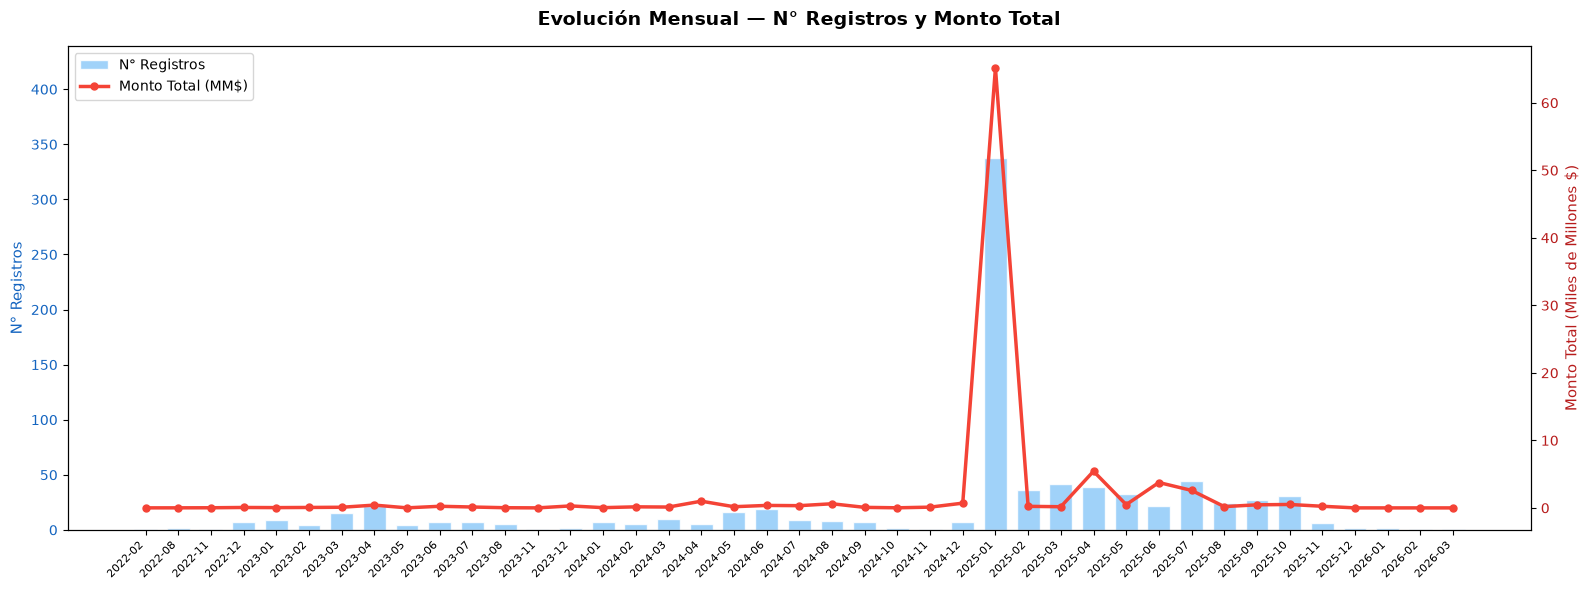

In [3]:
# Agrupar por periodo mensual
por_mes = df.groupby('periodo_mes').agg(
    n_registros=('ID Proyecto', 'count'),
    monto_total=('Monto Total Ítem Año 2025', 'sum')
).reset_index()
por_mes['periodo_str'] = por_mes['periodo_mes'].astype(str)
por_mes['monto_MM'] = por_mes['monto_total'] / 1e9

fig, ax1 = plt.subplots(figsize=(16, 6))

# Barras: n° registros
color_bar = '#90CAF9'
bars = ax1.bar(range(len(por_mes)), por_mes['n_registros'],
               color=color_bar, alpha=0.85, label='N° Registros', width=0.7, edgecolor='white')
ax1.set_xticks(range(len(por_mes)))
ax1.set_xticklabels(por_mes['periodo_str'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('N° Registros', color='#1565C0', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#1565C0')
ax1.set_ylim(0, por_mes['n_registros'].max() * 1.3)

# Línea: monto total
ax2 = ax1.twinx()
ax2.plot(range(len(por_mes)), por_mes['monto_MM'],
         color='#F44336', linewidth=2.5, marker='o', markersize=5,
         label='Monto Total (MM$)', zorder=5)
ax2.set_ylabel('Monto Total (Miles de Millones $)', color='#B71C1C', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#B71C1C')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Evolución Mensual — N° Registros y Monto Total', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fechas_evolucion_mensual.png', bbox_inches='tight', dpi=150)
plt.show()


## 2. Distribución por Mes del Año (Patrones Estacionales)

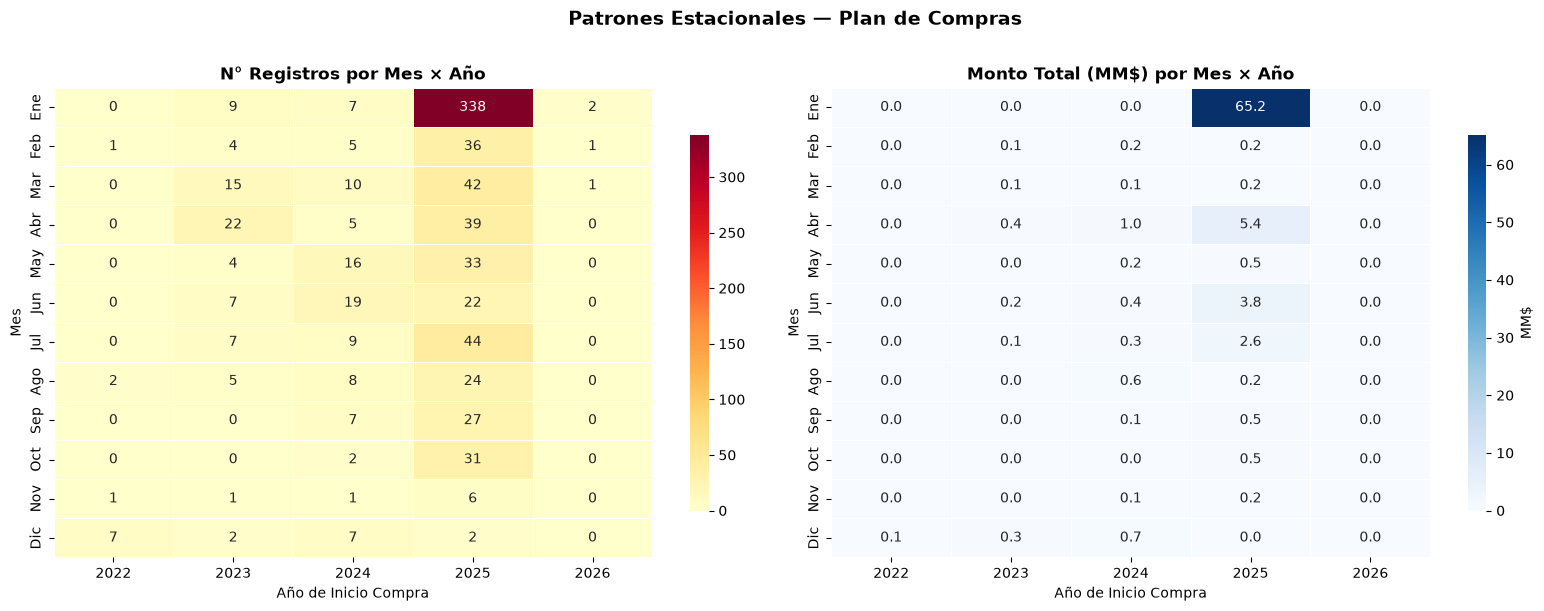

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: Mes × Año — N° registros
pivot_count = df.pivot_table(index='mes_inicio', columns='anio_inicio',
                              values='ID Proyecto', aggfunc='count', fill_value=0)
pivot_count.index = [MESES_ES.get(m, m) for m in pivot_count.index]

sns.heatmap(pivot_count, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('N° Registros por Mes × Año', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Año de Inicio Compra'); axes[0].set_ylabel('Mes')

# Heatmap: Mes × Año — Monto total (MM$)
pivot_monto = df.pivot_table(index='mes_inicio', columns='anio_inicio',
                              values='Monto Total Ítem Año 2025',
                              aggfunc='sum', fill_value=0) / 1e9
pivot_monto.index = [MESES_ES.get(m, m) for m in pivot_monto.index]

sns.heatmap(pivot_monto, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.8, 'label': 'MM$'})
axes[1].set_title('Monto Total (MM$) por Mes × Año', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Año de Inicio Compra'); axes[1].set_ylabel('Mes')

plt.suptitle('Patrones Estacionales — Plan de Compras', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fechas_heatmap_mes_anio.png', bbox_inches='tight', dpi=150)
plt.show()


## 3. Análisis por Trimestre

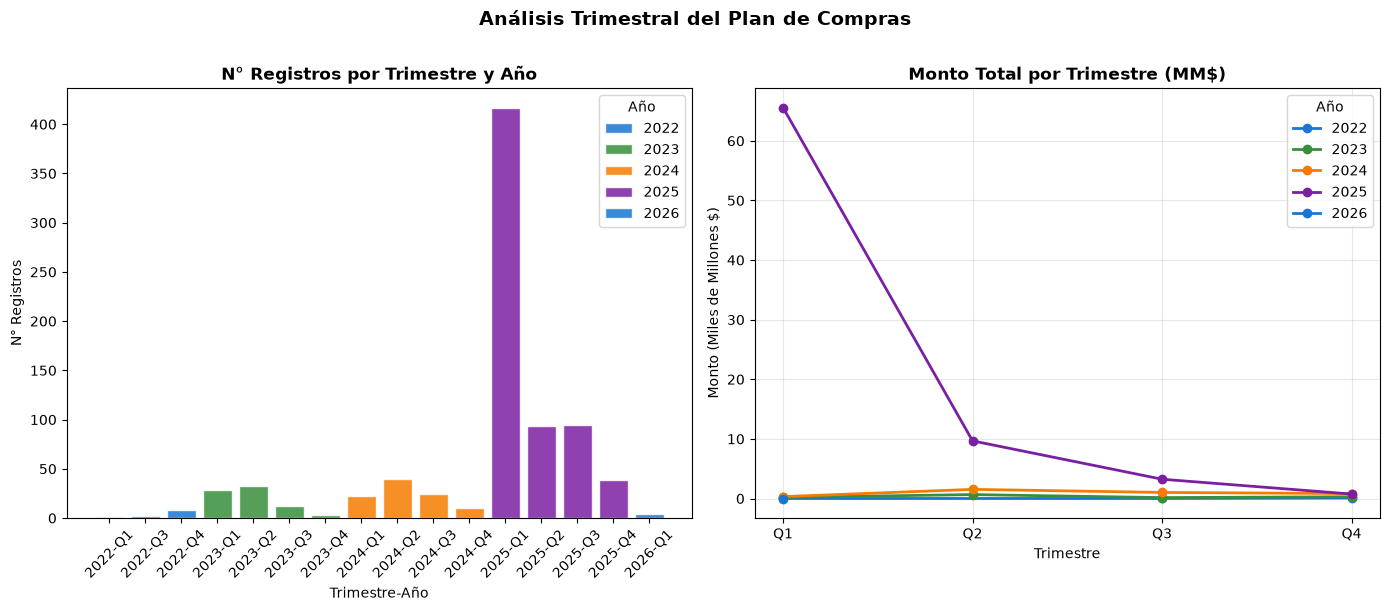

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

trim_data = df.groupby(['anio_inicio', 'trimestre']).agg(
    n=('ID Proyecto', 'count'),
    monto=('Monto Total Ítem Año 2025', 'sum')
).reset_index()
trim_data['label'] = trim_data['anio_inicio'].astype(str) + '-Q' + trim_data['trimestre'].astype(str)
trim_data['monto_MM'] = trim_data['monto'] / 1e9

# Barras N° registros por trimestre-año
colores_trim = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']
for i, (anio, grp) in enumerate(trim_data.groupby('anio_inicio')):
    axes[0].bar(grp['label'], grp['n'],
                label=str(anio), color=colores_trim[i % 4], alpha=0.85, edgecolor='white')
axes[0].set_title('N° Registros por Trimestre y Año', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trimestre-Año'); axes[0].set_ylabel('N° Registros')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Año')

# Monto por trimestre
for i, (anio, grp) in enumerate(trim_data.groupby('anio_inicio')):
    axes[1].plot(grp['trimestre'], grp['monto_MM'],
                 marker='o', linewidth=2, label=str(anio), color=colores_trim[i % 4])
axes[1].set_title('Monto Total por Trimestre (MM$)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Trimestre'); axes[1].set_ylabel('Monto (Miles de Millones $)')
axes[1].set_xticks([1,2,3,4]); axes[1].set_xticklabels(['Q1','Q2','Q3','Q4'])
axes[1].legend(title='Año')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis Trimestral del Plan de Compras', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fechas_trimestral.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Fecha Publicación PAC vs. Fecha de Inicio Compra

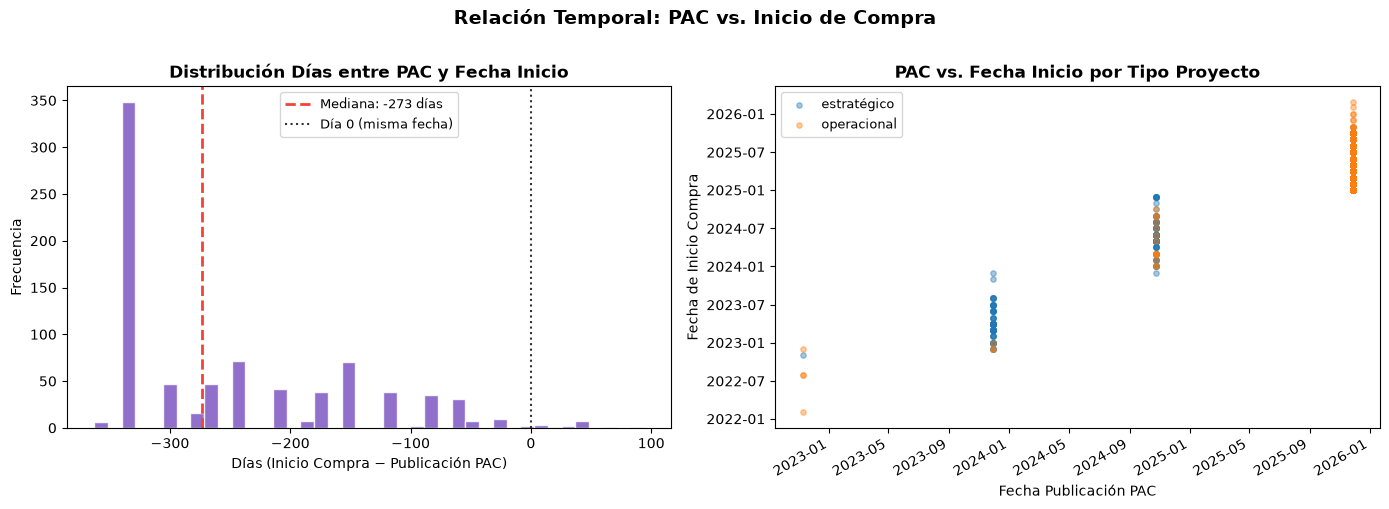

Diferencia promedio PAC→Inicio: -243 días
Diferencia mediana: -273 días


In [6]:
import matplotlib.dates as mdates

df_fechas = df.dropna(subset=['Fecha de Inicio Compra', 'Fecha Publicación PAC 2025']).copy()
df_fechas['dias_diferencia'] = (df_fechas['Fecha de Inicio Compra'] -
                                 df_fechas['Fecha Publicación PAC 2025']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma diferencia de días
axes[0].hist(df_fechas['dias_diferencia'], bins=40, color='#7E57C2',
             edgecolor='white', alpha=0.85)
axes[0].axvline(df_fechas['dias_diferencia'].median(), color='#F44336',
                linestyle='--', linewidth=2, label=f"Mediana: {df_fechas['dias_diferencia'].median():.0f} días")
axes[0].axvline(0, color='#333', linestyle=':', linewidth=1.5, label='Día 0 (misma fecha)')
axes[0].set_xlabel('Días (Inicio Compra − Publicación PAC)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución Días entre PAC y Fecha Inicio', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Dispersión Fecha PAC vs Fecha Inicio por tipo
for tipo, grp in df_fechas.groupby('Tipo Proyecto'):
    axes[1].scatter(grp['Fecha Publicación PAC 2025'],
                    grp['Fecha de Inicio Compra'],
                    alpha=0.4, s=15, label=tipo.replace('Proyecto ', ''))
axes[1].set_xlabel('Fecha Publicación PAC')
axes[1].set_ylabel('Fecha de Inicio Compra')
axes[1].set_title('PAC vs. Fecha Inicio por Tipo Proyecto', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.setp(axes[1].yaxis.get_majorticklabels(), rotation=0)

plt.suptitle('Relación Temporal: PAC vs. Inicio de Compra', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fechas_pac_vs_inicio.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Diferencia promedio PAC→Inicio: {df_fechas['dias_diferencia'].mean():.0f} días")
print(f"Diferencia mediana: {df_fechas['dias_diferencia'].median():.0f} días")


## 5. Monto Total por Mes de Inicio — Acumulado

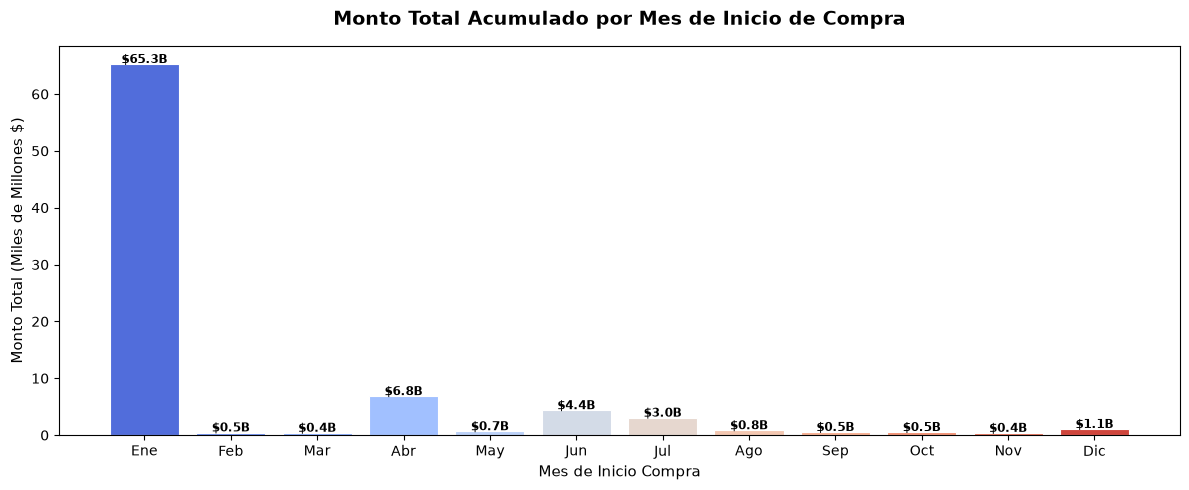

In [7]:
monto_mes = df.groupby('mes_inicio')['Monto Total Ítem Año 2025'].sum() / 1e9
monto_mes.index = [MESES_ES.get(m, str(m)) for m in monto_mes.index]

fig, ax = plt.subplots(figsize=(12, 5))
colores_mes = sns.color_palette("coolwarm", len(monto_mes))
bars = ax.bar(monto_mes.index, monto_mes.values,
              color=colores_mes, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Mes de Inicio Compra', fontsize=11)
ax.set_ylabel('Monto Total (Miles de Millones $)', fontsize=11)
ax.set_title('Monto Total Acumulado por Mes de Inicio de Compra', fontsize=14, fontweight='bold', pad=15)
for bar, val in zip(bars, monto_mes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'${val:.1f}B', ha='center', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.savefig('fechas_monto_por_mes.png', bbox_inches='tight', dpi=150)
plt.show()
